fichiers : 5
{'fichier': 'BNR4858a.cha', 'mots': 84, 'termes': 52, 'ttr': 0.619, 'mtld': 23.2398, 'simpsond': 0.0244}
{'fichier': 'CHP4775c.cha', 'mots': 42, 'termes': 31, 'ttr': 0.7381, 'mtld': 31.3266, 'simpsond': 0.0209}
{'fichier': 'DCR7644a.cha', 'mots': 382, 'termes': 119, 'ttr': 0.3115, 'mtld': 29.1752, 'simpsond': 0.0243}
{'fichier': 'depaul1a.cha', 'mots': 2525, 'termes': 418, 'ttr': 0.1655, 'mtld': 43.9581, 'simpsond': 0.0159}
{'fichier': 'LBY4645a.cha', 'mots': 469, 'termes': 176, 'ttr': 0.3753, 'mtld': 36.2268, 'simpsond': 0.026}


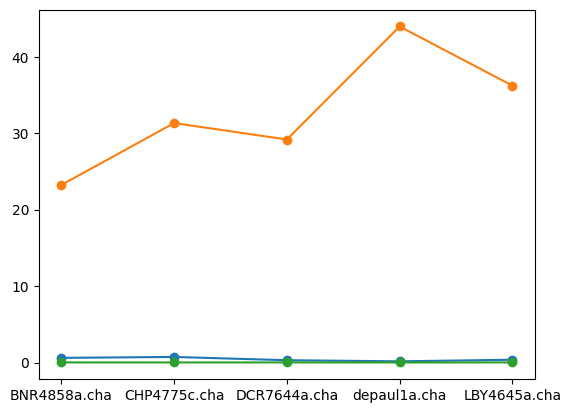

In [17]:
from pylangacq import CHAT
from pandas import DataFrame
from lexicalrichness import LexicalRichness
from matplotlib.pyplot import plot
import glob 

#chemin relatif 
fichiers = glob.glob("corpus/*.cha")
print("fichiers : " f"{len(fichiers)}")
 
#lex = LexicalRichness(texte_par)
#print(lex.simpsond) 
#print(lex) 

#analyse linguistique / fichier 
data=[]

for fichier in fichiers:
    corpus = CHAT.from_files([fichier])
    all_utterances = corpus.utterances()
    par = [u for u in all_utterances if u.participant == "PAR"]
    inv = [u for u in all_utterances if u.participant == "INV"]

    texte_par = " ".join(" ".join(t.word for t in u.tokens) for u in par)
    lex = LexicalRichness(texte_par)

    data.append({
        "fichier"    : fichier.split("\\")[-1],  # nom du fichier seul
        "mots"       : lex.words,
        "termes"     : lex.terms,
        "ttr"        : round(lex.ttr, 4),
        "mtld"       : round(lex.mtld(), 4),
        "simpsond"   : round(lex.simpsond, 4),
    })

#afficher les données en liste 
for d in data:
    print(d)


#Courbes : 
metriques = ["ttr", "mtld", "simpsond"]
labels = [d["fichier"] for d in data]
for m in metriques: 
    plot(labels, [d[m] for d in data], marker="o", label=m.upper())



    
#df = DataFrame(data)
#print(df.to_string(index=False))

#for u in par : 
    #mots = " ".join(t.word for t in u.tokens)
    #print(mots)